# Import Library

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import pandas_gbq
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Mengkoneksikan ke data Bigquery

In [ ]:
from google.colab import auth
auth.authenticate_user()

In [ ]:
from google.cloud import bigquery

client=bigquery.Client(project='da-2025-481513')

In [ ]:
query = """
  SELECT * FROM `da-2025-481513.Country_dataset.country_data`
"""
client.query(query).to_dataframe()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Haiti,208.0,15.3,6.91,64.7,1500,5.450,32.1,3.33,662
1,Lesotho,99.7,39.4,11.10,101.0,2380,4.150,46.5,3.30,1170
2,Central African Republic,149.0,11.8,3.98,26.5,888,2.010,47.5,5.21,446
3,Zambia,83.1,37.0,5.89,30.9,3280,14.000,52.0,5.40,1460
4,Malawi,90.5,22.8,6.59,34.9,1030,12.100,53.1,5.31,459
...,...,...,...,...,...,...,...,...,...,...
162,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900
163,Iceland,2.6,53.4,9.40,43.3,38800,5.470,82.0,2.20,41900
164,Switzerland,4.5,64.0,11.50,53.3,55500,0.317,82.2,1.52,74600
165,Singapore,2.8,200.0,3.96,174.0,72100,-0.046,82.7,1.15,46600


# Cleaning Dataset

In [ ]:
query = """
  SELECT * FROM `da-2025-481513.Country_dataset.country_data`
"""
client.query(query).to_dataframe()
print("Checking for missing value in the query result:")
print(client.query(query).to_dataframe().isnull().sum())

Checking for missing value in the query result:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


In [ ]:
query = """
  SELECT * FROM `da-2025-481513.Country_dataset.country_data`
"""
df_bq_test = client.query(query).to_dataframe()

print("\nChecking for duplicate rows before dropping:")
print(df_bq_test.duplicated().sum())

df_bq_test.drop_duplicates(inplace=True)

print("\nChecking for duplicate rows after dropping:")
print(df_bq_test.duplicated().sum())


Checking for duplicate rows before dropping:
0

Checking for duplicate rows after dropping:
0


# Info Column Data

In [ ]:
df_bq_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    Int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    Int64  
dtypes: Int64(2), float64(7), object(1)
memory usage: 13.5+ KB


# Describe Data

In [ ]:
df_bq_test.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.0,167.000000,167.000000,167.000000,167.0
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.0,-4.210000,32.100000,1.150000,231.0
25%,8.250000,23.800000,4.920000,30.200000,3355.0,1.810000,65.300000,1.795000,1330.0
50%,19.300000,35.000000,6.320000,43.300000,9960.0,5.390000,73.100000,2.410000,4660.0
75%,62.100000,51.350000,8.600000,58.750000,22800.0,10.750000,76.800000,3.880000,14050.0
max,208.000000,200.000000,17.900000,174.000000,125000.0,104.000000,82.800000,7.490000,105000.0


## Total Jumlah Data

In [ ]:
rows, cols = df_bq_test.shape
print(f"Total baris data: {rows}")
print(f"Total kolom data: {cols}")

Total baris data: 167
Total kolom data: 10


# Bikin function biar mempermudah

In [ ]:
def execute(query):
  return client.query(query).to_dataframe()

# BAB 1

## Tugas 1.1 (Profil Kesenjangan Ekonomi): Hitung total negara dan rentang kekayaan (GDP Minimal dan Maksimal).

In [ ]:
# Tugas 1.1
execute ("""
  SELECT
  COUNT(country) AS total_negara,
  MIN(gdpp) AS gdp_minimal,
  MAX(gdpp) AS gdp_maksimal,
  MAX (gdpp) - MIN (gdpp) AS rentang_kekayaan
FROM `da-2025-481513.Country_dataset.country_data`;
""")
#Tabel 1.1

,total_negara,gdp_minimal,gdp_maksimal,rentang_kekayaan
0,167,231,105000,104769


## Tugas 1.2 (Analisis Tingkat Fertilitas): Identifikasi 5 negara dengan tingkat kesuburan tertinggi.

In [ ]:
# Tugas 1.2
tingkat_fertilitas = execute("""SELECT
  country,
  total_fer AS tingkat_fertilitas
FROM `da-2025-481513.Country_dataset.country_data`
ORDER BY total_fer DESC
LIMIT 5;""")

tingkat_fertilitas
# Tabel 1.2

,country,tingkat_fertilitas
0,Niger,7.49
1,Chad,6.59
2,Mali,6.55
3,"Congo, Dem. Rep.",6.54
4,Burundi,6.26


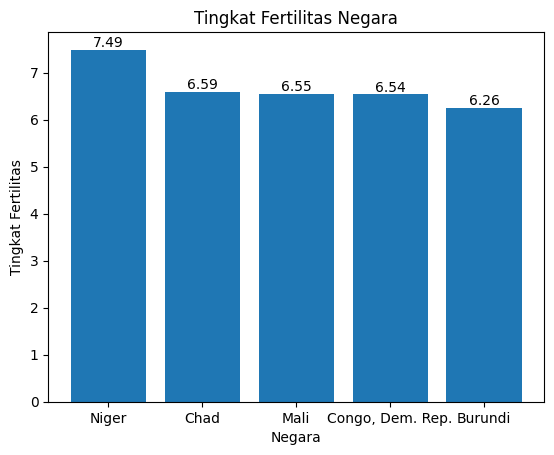

In [ ]:
plt.bar(
    x=tingkat_fertilitas['country'],
    height=tingkat_fertilitas['tingkat_fertilitas'],
)
ax = plt.gca()

plt.title("Tingkat Fertilitas Negara")
plt.xlabel("Negara")
plt.ylabel("Tingkat Fertilitas")

# Buat label data
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.show()

## Tugas 1.3 (Analisis Harapan Hidup): Daftar 5 negara dengan angka harapan hidup terendah.

In [ ]:
# Tugas 1.3
harapan_hidup = execute("""SELECT
  country,
  life_expec AS harapan_hidup
FROM `da-2025-481513.Country_dataset.country_data` ORDER BY life_expec ASC
LIMIT 5;""")

harapan_hidup

,country,harapan_hidup
0,Haiti,32.1
1,Lesotho,46.5
2,Central African Republic,47.5
3,Zambia,52.0
4,Malawi,53.1


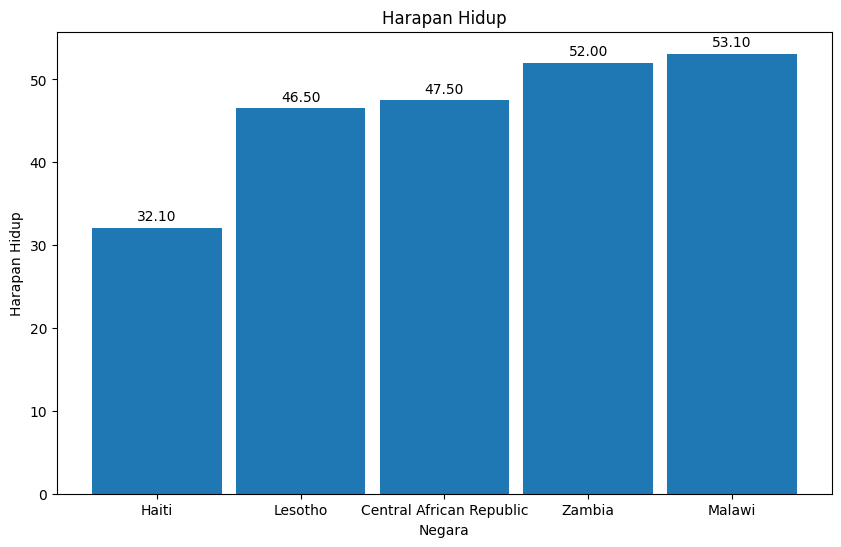

In [ ]:
# Perbesar kanvas
plt.figure(figsize=(10, 6))

plt.bar(
    x=harapan_hidup['country'],
    height=harapan_hidup['harapan_hidup'],
    width=0.9
)

ax = plt.gca()

plt.title("Harapan Hidup")
plt.xlabel("Negara")
plt.ylabel("Harapan Hidup")

# Buat label data
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f',
        padding=3,
        fontsize=10
    )

plt.show()


## Tugas 1.4 (Identifikasi Inflasi Tinggi): Cari 5 negara dengan tingkat inflasi tertinggi untuk mengukur stabilitas ekonomi.

In [ ]:
# Tugas 1.4
tingkat_inflasi = execute("""SELECT
  country,
  inflation AS tingkat_inflasi
FROM `da-2025-481513.Country_dataset.country_data`
ORDER BY inflation DESC
LIMIT 5;""")

tingkat_inflasi

,country,tingkat_inflasi
0,Nigeria,104.0
1,Venezuela,45.9
2,Mongolia,39.2
3,Timor-Leste,26.5
4,Equatorial Guinea,24.9


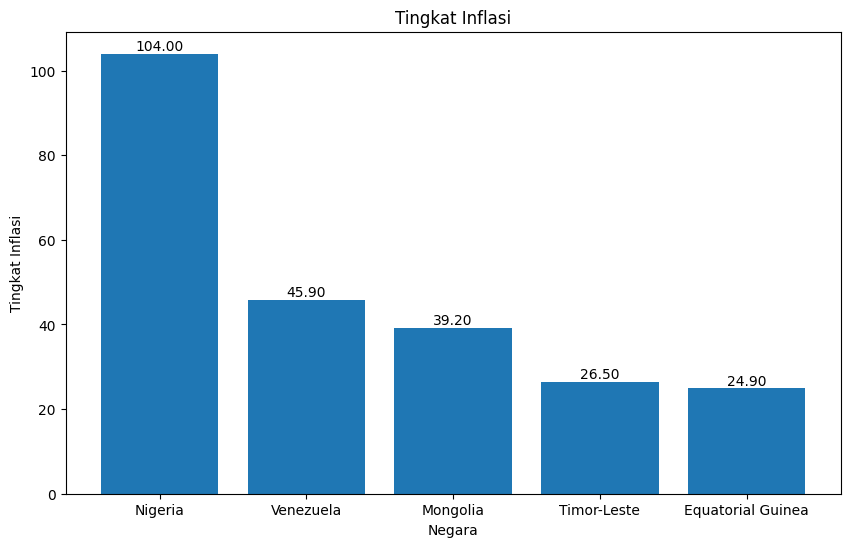

In [ ]:
# Perbesar kanvas
plt.figure(figsize=(10, 6))

plt.bar(
    x=tingkat_inflasi['country'],
    height=tingkat_inflasi['tingkat_inflasi'],
)

ax = plt.gca()

plt.title("Tingkat Inflasi")
plt.xlabel("Negara")
plt.ylabel("Tingkat Inflasi")

# Buat label data
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.show()

## Tugas 1.5 (Hubungan Pendapatan dan Kesehatan): Bandingkan 5 negara dengan pendapatan tertinggi terhadap 5 negara dengan angka kematian anak terendah.

In [ ]:
# Tugas 1.5
hubungan_pendapatan_kesehatan = execute ("""
SELECT country, gdpp, child_mort
FROM `da-2025-481513.Country_dataset.country_data`
WHERE country IN (
    SELECT country FROM `da-2025-481513.Country_dataset.country_data` ORDER BY gdpp DESC LIMIT 5
)
OR country IN (
    SELECT  country FROM `da-2025-481513.Country_dataset.country_data` ORDER BY child_mort ASC LIMIT 5
);""")

hubungan_pendapatan_kesehatan

,country,gdpp,child_mort
0,Denmark,58000,4.1
1,Qatar,70300,9.0
2,Finland,46200,3.0
3,Norway,87800,3.2
4,Luxembourg,105000,2.8
5,Sweden,52100,3.0
6,Iceland,41900,2.6
7,Switzerland,74600,4.5
8,Singapore,46600,2.8


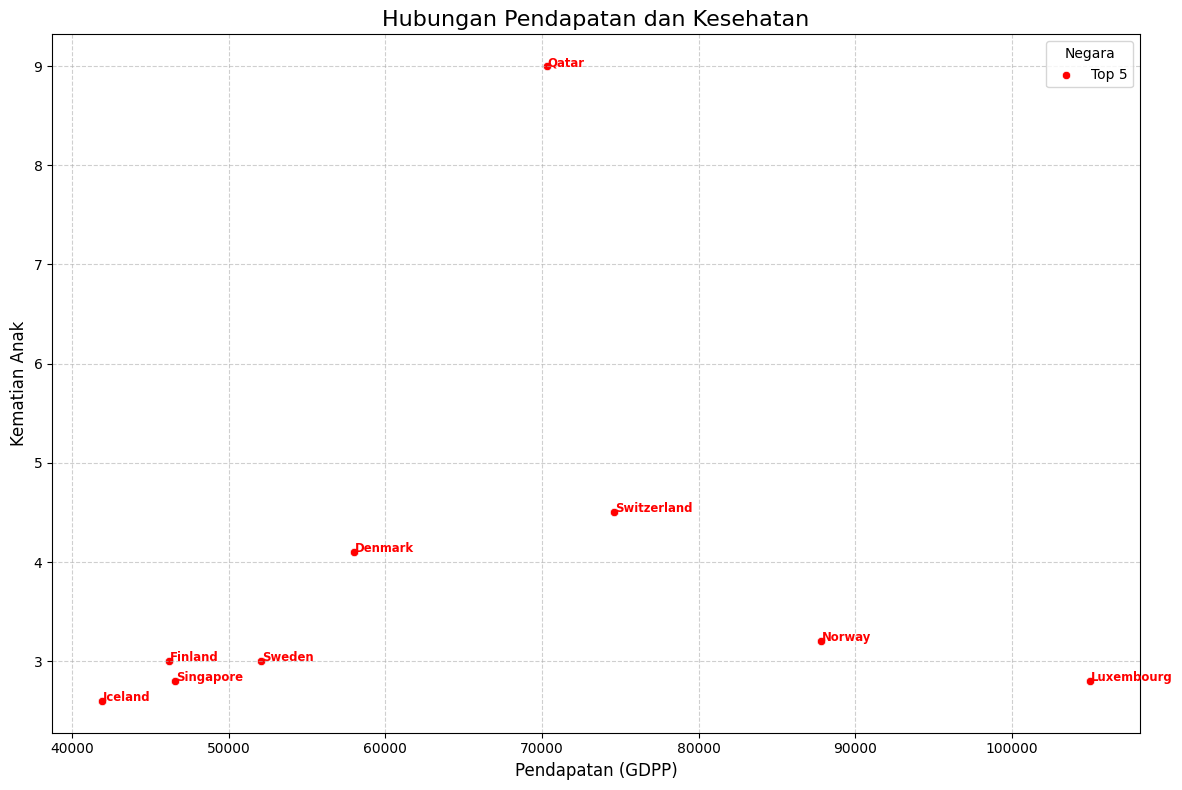

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=hubungan_pendapatan_kesehatan, x='gdpp', y='child_mort')
sns.scatterplot(data=hubungan_pendapatan_kesehatan, x='gdpp', y='child_mort', color='red', label='Top 5' )
for i, row in hubungan_pendapatan_kesehatan.iterrows():
  plt.text(row['gdpp'] + 50, row['child_mort'], row['country'], horizontalalignment='left', size='small', color='red', weight='semibold')

plt.title('Hubungan Pendapatan dan Kesehatan', fontsize=16)
plt.xlabel('Pendapatan (GDPP)', fontsize=12)
plt.ylabel('Kematian Anak', fontsize=12)
plt.legend(title='Negara', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("output.png")
plt.show()

# BAB **2**

## Tugas 2.1 (Konversi Anggaran Kesehatan ke USD): Hitung pengeluaran kesehatan aktual per orang dalam mata uang USD.

In [ ]:
# Tugas 2.1

anggaran_kesehatan_USD = execute("""
SELECT
  country,
  health AS persentase_kesehatan,
  gdpp AS pendapatan_per_kapita,
  ROUND((health / 100) * gdpp, 2) AS pengeluaran_kesehatan_usd
FROM `da-2025-481513.Country_dataset.country_data`;
""")

anggaran_kesehatan_USD

,country,persentase_kesehatan,pendapatan_per_kapita,pengeluaran_kesehatan_usd
0,Haiti,6.91,662,45.74
1,Lesotho,11.10,1170,129.87
2,Central African Republic,3.98,446,17.75
3,Zambia,5.89,1460,85.99
4,Malawi,6.59,459,30.25
...,...,...,...,...
162,Australia,8.73,51900,4530.87
163,Iceland,9.40,41900,3938.60
164,Switzerland,11.50,74600,8579.00
165,Singapore,3.96,46600,1845.36


/tmp/ipython-input-1318056890.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


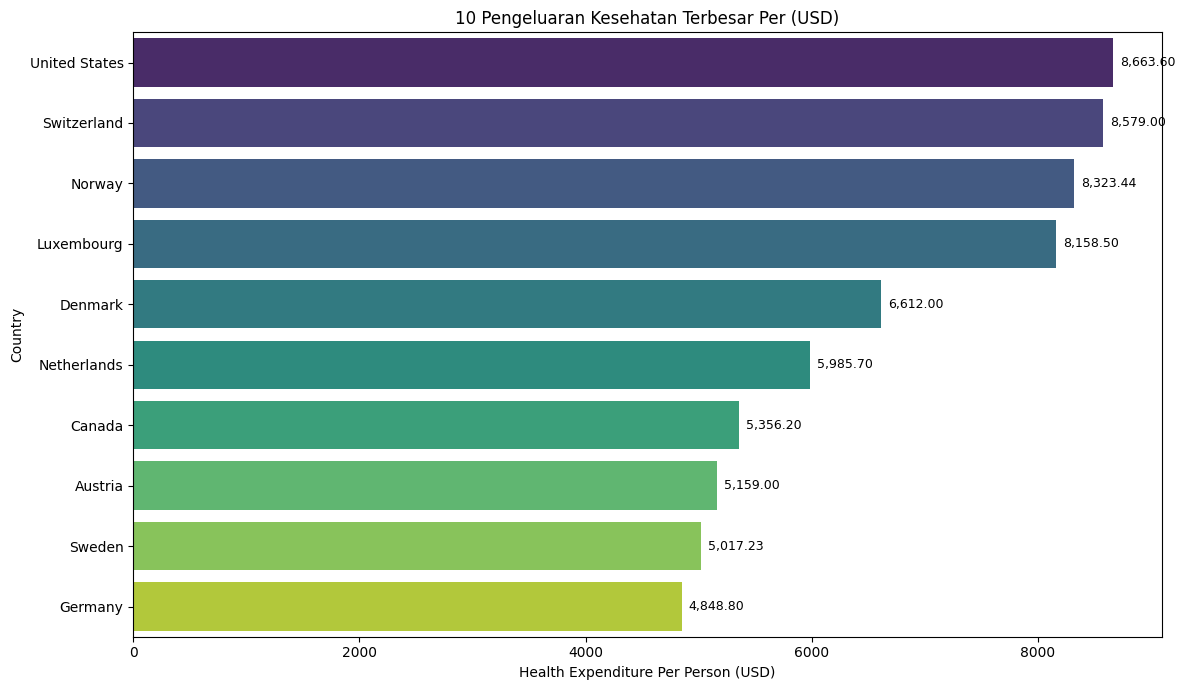

In [ ]:
plt.figure(figsize=(12, 7))

# Ambil TOP 10 dari HASIL QUERY
df_plot_sorted = (
    anggaran_kesehatan_USD
    .sort_values(by='pengeluaran_kesehatan_usd', ascending=False)
    .head(10)
)

# Bar chart
ax = sns.barplot(
    data=df_plot_sorted,
    x='pengeluaran_kesehatan_usd',
    y='country',
    palette='viridis'
)

plt.title('10 Pengeluaran Kesehatan Terbesar Per (USD)')
plt.xlabel('Health Expenditure Per Person (USD)')
plt.ylabel('Country')

# Label angka
for p in ax.patches:
    ax.annotate(
        f'{p.get_width():,.2f}',
        (p.get_width(), p.get_y() + p.get_height() / 2),
        ha='left',
        va='center',
        xytext=(5, 0),
        textcoords='offset points',
        fontsize=9
    )

plt.tight_layout()
plt.show()


## Tugas 2.2 (Analisis Neraca Perdagangan): Hitung selisih ekspor dan impor dalam USD. Rumus: (exports - imports) * (gdpp / 100).

In [ ]:
# Tugas 2.2

analisis_neraca_perdagangan = execute("""
SELECT country,exports, imports,
ROUND((exports - imports) * (gdpp / 100), 2) AS selisih_ekspor_impor
FROM `da-2025-481513.Country_dataset.country_data`;
""")

analisis_neraca_perdagangan

,country,exports,imports,selisih_ekspor_impor
0,Haiti,15.3,64.7,-327.03
1,Lesotho,39.4,101.0,-720.72
2,Central African Republic,11.8,26.5,-65.56
3,Zambia,37.0,30.9,89.06
4,Malawi,22.8,34.9,-55.54
...,...,...,...,...
162,Australia,19.8,20.9,-570.90
163,Iceland,53.4,43.3,4231.90
164,Switzerland,64.0,53.3,7982.20
165,Singapore,200.0,174.0,12116.00


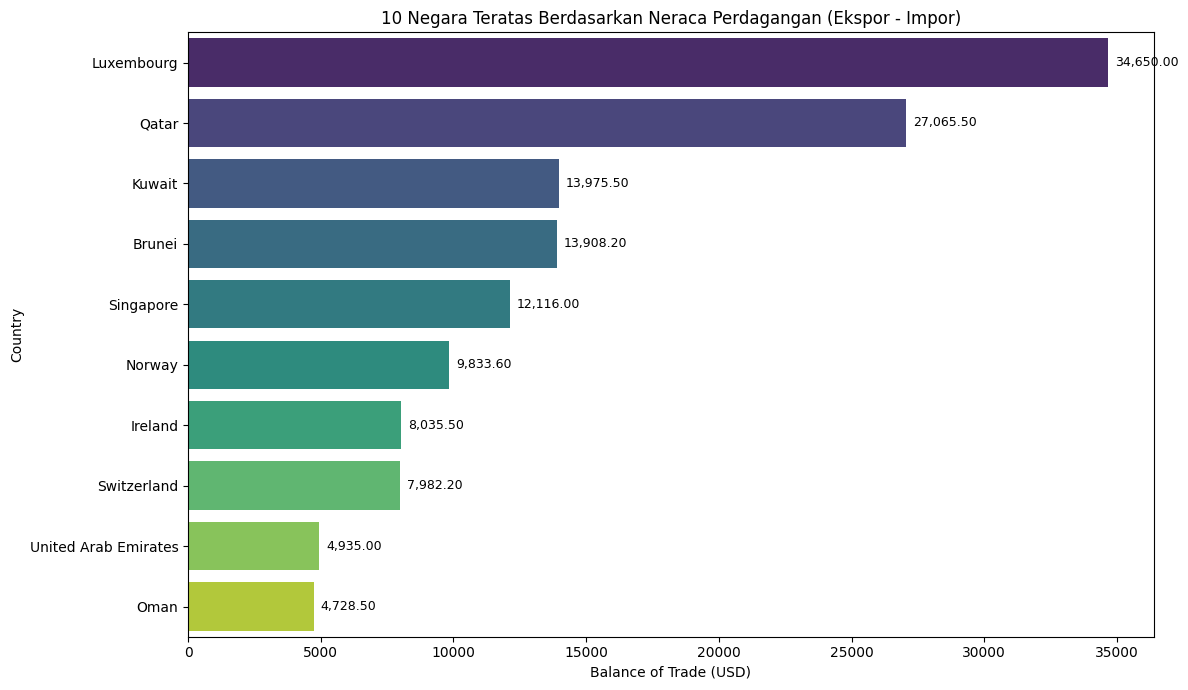

In [ ]:
# Memilih 10 Negara dengan 'selisih_ekspor_impor'
df_plot_top_10_trade_balance = (
    analisis_neraca_perdagangan
    .sort_values(by='selisih_ekspor_impor', ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 7))

# Membuat bar chart nya
ax = sns.barplot(
    data=df_plot_top_10_trade_balance,
    x='selisih_ekspor_impor',
    y='country',
    palette='viridis',
    hue='country',
    legend=False
)

plt.title('10 Negara Teratas Berdasarkan Neraca Perdagangan (Ekspor - Impor)')
plt.xlabel('Balance of Trade (USD)')
plt.ylabel('Country')

# Menambahkan label data
for p in ax.patches:
    ax.annotate(
        f'{p.get_width():,.2f}',
        (p.get_width(), p.get_y() + p.get_height() / 2),
        ha='left',
        va='center',
        xytext=(5, 0),
        textcoords='offset points',
        fontsize=9
    )

plt.tight_layout()
plt.show()


## Tugas 2.3 (Perbandingan Produksi vs Pendapatan): Hitung selisih antara nilai produksi negara (GDP) dan pendapatan aktual warga negaranya (Income).

In [ ]:
# Tugas 2.3

perbandingan_produksi_pendapatan = execute("""
SELECT country, gdpp, income,
ROUND((gdpp - income),2) AS selisih_pendapatan_keuntungan
FROM `da-2025-481513.Country_dataset.country_data`;
""")

perbandingan_produksi_pendapatan

,country,gdpp,income,selisih_pendapatan_keuntungan
0,Haiti,662,1500,-838.0
1,Lesotho,1170,2380,-1210.0
2,Central African Republic,446,888,-442.0
3,Zambia,1460,3280,-1820.0
4,Malawi,459,1030,-571.0
...,...,...,...,...
162,Australia,51900,41400,10500.0
163,Iceland,41900,38800,3100.0
164,Switzerland,74600,55500,19100.0
165,Singapore,46600,72100,-25500.0


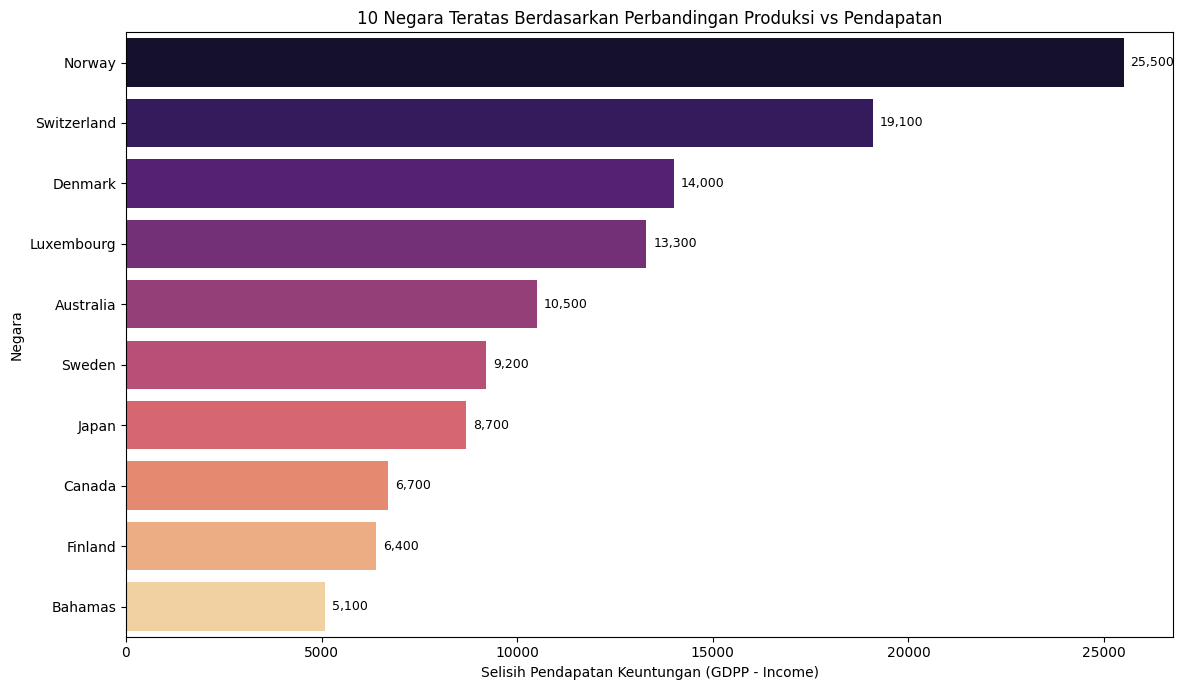

In [ ]:
# Memilih 10 Negara dengan 'selisih_pendapatan_keuntungan' tertinggi
df_plot_selisih_pendapatan = (
    perbandingan_produksi_pendapatan
    .sort_values(by='selisih_pendapatan_keuntungan', ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 7))

# Membuat bar chart
ax = sns.barplot(
    data=df_plot_selisih_pendapatan,
    x='selisih_pendapatan_keuntungan',
    y='country',
    palette='magma',
    hue='country',
    legend=False
)

plt.title('10 Negara Teratas Berdasarkan Perbandingan Produksi vs Pendapatan')
plt.xlabel('Selisih Pendapatan Keuntungan (GDPP - Income)')
plt.ylabel('Negara')

# Menambahkan label data
for p in ax.patches:
    ax.annotate(
        f'{p.get_width():,.0f}',
        (p.get_width(), p.get_y() + p.get_height() / 2),
        ha='left',
        va='center',
        xytext=(5, 0),
        textcoords='offset points',
        fontsize=9
    )

plt.tight_layout()
plt.show()

*   **Perbedaan Positif Terbesar:** Menunjukkan negara-negara di mana GDP per kapita jauh lebih tinggi dari pendapatan per kapita. Ini bisa mengindikasikan surplus produksi yang besar atau struktur ekonomi tertentu.
*   **Perbedaan Negatif Terbesar:** Menunjukkan negara-negara di mana pendapatan per kapita warga negaranya lebih tinggi dari GDP per kapita. Hal ini mungkin terjadi di negara-negara yang banyak menerima pendapatan dari luar negeri (misalnya, remitansi atau investasi asing) atau memiliki struktur perpajakan yang unik.

# BAB **3**

## Tugas 3.1 (Segmentasi Tingkat Ekonomi): Kategorikan negara menjadi Rendah (<$2000), Menengah ($2000-$10000), dan Tinggi (>$10000) berdasarkan GDP. Hitung rata-rata angka kematian anak untuk setiap kategori.

In [ ]:
# Tugas 3.1

kategori_tingkat_ekonomi = execute("""SELECT
CASE
  WHEN gdpp < 2000 THEN 'Rendah'
  WHEN gdpp >= 2000 AND gdpp <= 10000 THEN 'Menengah'
  ELSE 'Tinggi'
END AS kategori_ekonomi,
ROUND(AVG (child_mort),2) AS rata_rata_kematian_anak
FROM `da-2025-481513.Country_dataset.country_data`
GROUP BY kategori_ekonomi;""")

kategori_tingkat_ekonomi

,kategori_ekonomi,rata_rata_kematian_anak
0,Rendah,84.03
1,Menengah,28.69
2,Tinggi,9.18


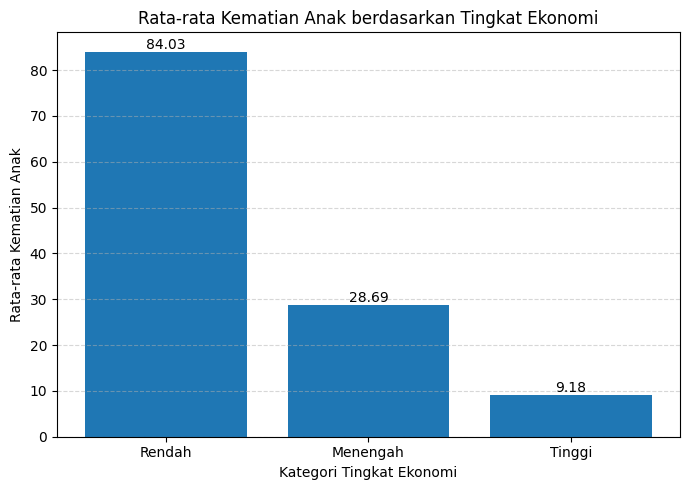

In [ ]:
plt.figure(figsize=(7,5))

plt.bar(
    kategori_tingkat_ekonomi['kategori_ekonomi'],
    kategori_tingkat_ekonomi['rata_rata_kematian_anak']
)

ax = plt.gca()

plt.title("Rata-rata Kematian Anak berdasarkan Tingkat Ekonomi")
plt.xlabel("Kategori Tingkat Ekonomi")
plt.ylabel("Rata-rata Kematian Anak")

# Tambahkan label data
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()


plt.show()

*   **Kategori Rendah (Low GDP):** Negara-negara dengan GDP per kapita di bawah $2000 memiliki rata-rata angka kematian anak tertinggi.

*   **Kategori Menengah (Medium GDP):** Negara-negara dengan GDP per kapita antara $2000 hingga $10000 memiliki rata-rata angka kematian anak yang lebih rendah dibandingkan kategori rendah.

*   **Kategori Tinggi (High GDP):** Negara-negara dengan GDP per kapita di atas $10000 memiliki rata-rata angka kematian anak terendah, menunjukkan korelasi terbalik antara tingkat GDP dan angka kematian anak.

## Tugas 3.2 (Segmentasi Tingkat Fertilitas): Kategorikan berdasarkan angka kesuburan:Rendah (<2), Menengah (2-4), dan Tinggi (>4). Hitung rata-rata pendapatan warga untuk kelompok Tinggi.

In [ ]:
# Tugas 3.2

kategori_tingkat_kesuburan = execute("""
SELECT
CASE
  WHEN total_fer < 2 THEN 'Rendah'
  WHEN total_fer >= 2 AND total_fer <= 4 THEN 'Menengah'
  ELSE 'Tinggi'
END AS kategori_kesuburan,
ROUND(AVG(income),2) AS rata_rata_pendapatan_kelompok_tinggi
FROM `da-2025-481513.Country_dataset.country_data`
GROUP BY kategori_kesuburan
HAVING kategori_kesuburan = 'Tinggi';""")

kategori_tingkat_kesuburan

,kategori_kesuburan,rata_rata_pendapatan_kelompok_tinggi
0,Tinggi,3532.76


/tmp/ipython-input-3985889766.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


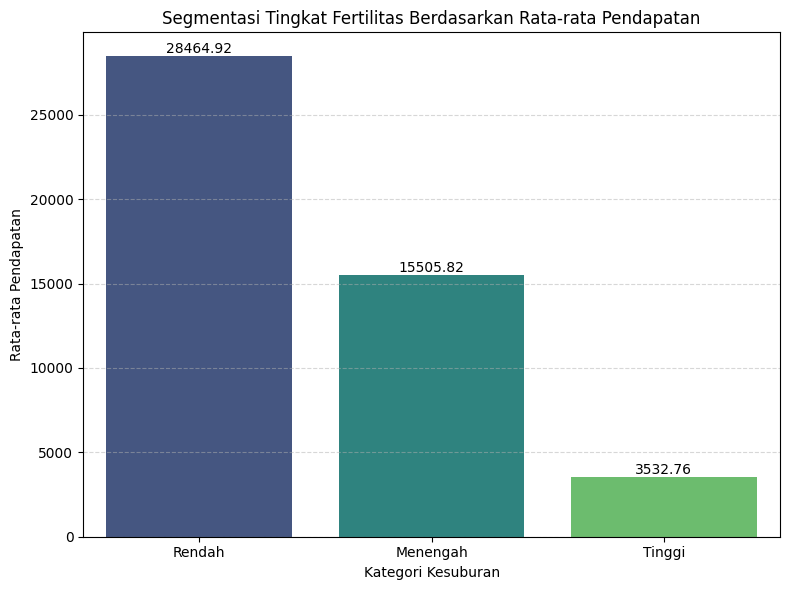

In [ ]:
# Hitung kesuburan 'Rendah' ​​menggunakan df_bq_test
rendah_income = df_bq_test[df_bq_test['total_fer'] < 2]['income'].mean()
df_rendah = pd.DataFrame([{'kategori_kesuburan': 'Rendah', 'rata_rata_pendapatan_kelompok_tinggi': round(rendah_income, 2)}])

# Hitung kesuburan 'Menengah' ​​menggunakan df_bq_test
menengah_income = df_bq_test[(df_bq_test['total_fer'] >= 2) & (df_bq_test['total_fer'] <= 4)]['income'].mean()
df_menengah = pd.DataFrame([{'kategori_kesuburan': 'Menengah', 'rata_rata_pendapatan_kelompok_tinggi': round(menengah_income, 2)}])

# Gabungkan ketiga dataframe
df_combined_fertility = pd.concat([df_rendah, df_menengah, kategori_tingkat_kesuburan], ignore_index=True)

# Tentukan urutan plot dan pengurutan
category_order = ['Rendah', 'Menengah', 'Tinggi']
df_combined_fertility['kategori_kesuburan'] = pd.Categorical(df_combined_fertility['kategori_kesuburan'], categories=category_order, ordered=True)
df_combined_fertility = df_combined_fertility.sort_values('kategori_kesuburan')

plt.figure(figsize=(8, 6))
ax = sns.barplot(
    data=df_combined_fertility,
    x='kategori_kesuburan',
    y='rata_rata_pendapatan_kelompok_tinggi',
    palette='viridis'
)

plt.title("Segmentasi Tingkat Fertilitas Berdasarkan Rata-rata Pendapatan")
plt.xlabel("Kategori Kesuburan")
plt.ylabel("Rata-rata Pendapatan")

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Tugas 3.3 (Dampak Inflasi terhadap Harapan Hidup): Kategorikan inflasi menjadi Stabil (<5%), Moderat (5-15%), dan Tinggi (>15%). Hitung rata-rata harapan hidup untuk masing-masing kelompok tersebut.

In [ ]:
# Tugas 3.3

kategori_inflasi = execute("""SELECT
CASE
  WHEN inflation < 5 THEN 'Stabil'
  WHEN inflation >= 5 AND inflation <= 15 THEN 'Moderat'
  ELSE 'Tinggi'
END AS kategori_inflasi,
ROUND(AVG(life_expec),2) AS rata_rata_harapan_hidup
FROM `da-2025-481513.Country_dataset.country_data`
GROUP BY kategori_inflasi;""")

kategori_inflasi

,kategori_inflasi,rata_rata_harapan_hidup
0,Moderat,68.02
1,Stabil,73.30
2,Tinggi,67.67


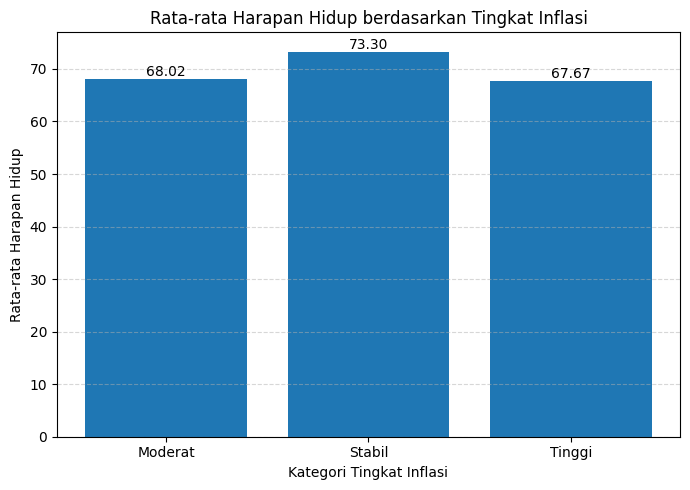

In [ ]:
plt.figure(figsize=(7,5))

plt.bar(
    kategori_inflasi['kategori_inflasi'],
    kategori_inflasi['rata_rata_harapan_hidup']
)

ax = plt.gca()

plt.title("Rata-rata Harapan Hidup berdasarkan Tingkat Inflasi")
plt.xlabel("Kategori Tingkat Inflasi")
plt.ylabel("Rata-rata Harapan Hidup")

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# Tambahkan label data
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

# BAB **4**

# Tugas 4.1 (Menentukan Ambang Batas Statistik)

In [ ]:
# Tugas 4.1

ambang_batas_statistik = execute("""WITH threshold AS (
  SELECT
    PERCENTILE_CONT(gdpp, 0.25) OVER() AS ambang_kemiskinan,
    PERCENTILE_CONT(child_mort, 0.75) OVER() AS ambang_krisis_kesehatan
  FROM `da-2025-481513.Country_dataset.country_data`
)

SELECT DISTINCT
  ambang_kemiskinan,
  ambang_krisis_kesehatan
FROM threshold;""")

ambang_batas_statistik

,ambang_kemiskinan,ambang_krisis_kesehatan
0,1330.0,62.1


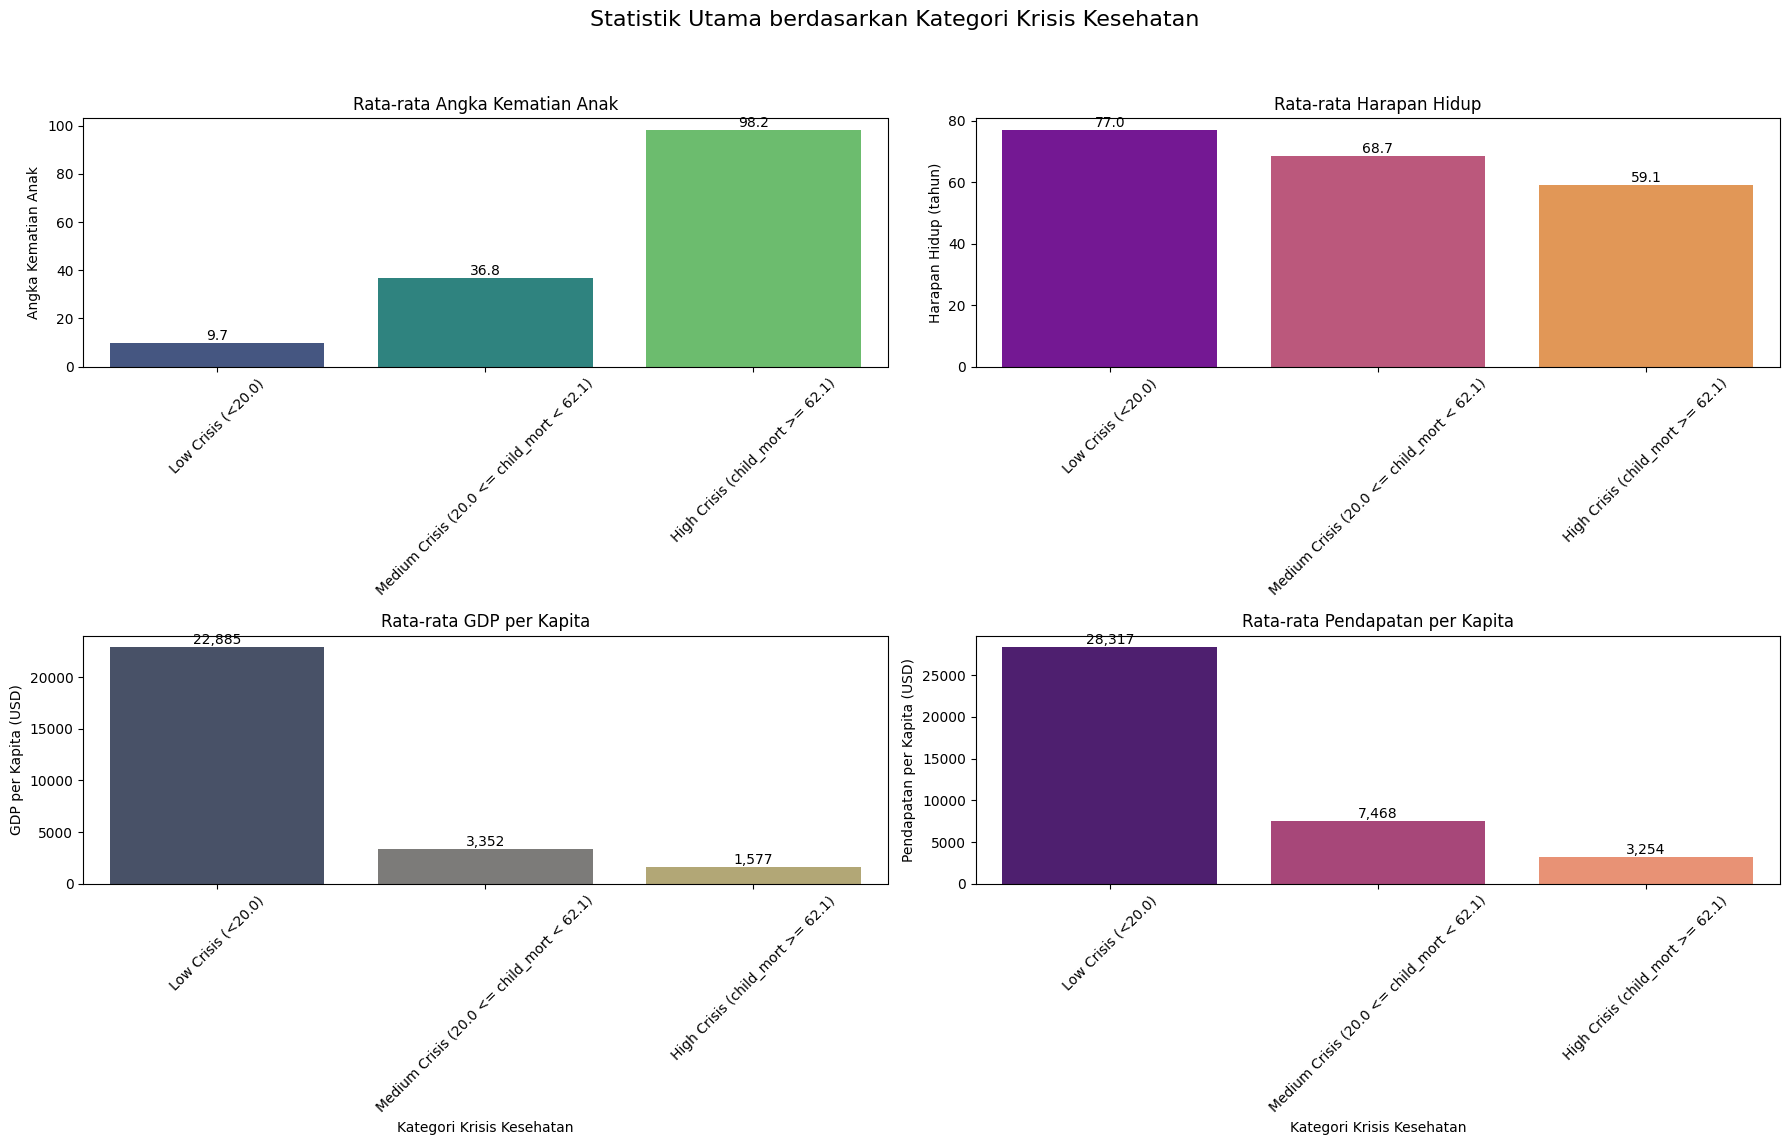

In [ ]:
# Ekstrak ambang batas dari ambang_batas_statistik
ambang_kemiskinan = ambang_batas_statistik['ambang_kemiskinan'].iloc[0]
ambang_krisis_kesehatan = ambang_batas_statistik['ambang_krisis_kesehatan'].iloc[0]
df_temp = df_bq_test.copy()

# Tentukan kategori krisis kesehatan berdasarkan child_mort dan ambang_krisis_kesehatan
def categorize_health_crisis(child_mort):
    if child_mort >= ambang_krisis_kesehatan:
        return f'High Crisis (child_mort >= {ambang_krisis_kesehatan:.1f})'
    elif child_mort >= 20.0:
        return f'Medium Crisis (20.0 <= child_mort < {ambang_krisis_kesehatan:.1f})'
    else:
        return 'Low Crisis (<20.0)'

df_temp['Health_Crisis_Category'] = df_temp['child_mort'].apply(categorize_health_crisis)

# Hitung statistik rata-rata untuk setiap kategori krisis kesehatan
health_crisis_stats = df_temp.groupby('Health_Crisis_Category').agg(
    avg_child_mort=('child_mort', 'mean'),
    avg_life_expec=('life_expec', 'mean'),
    avg_gdpp=('gdpp', 'mean'),
    avg_income=('income', 'mean')
).reset_index()

# Pastikan Kategori Krisis Kesehatan diurutkan agar plotting benar
category_order = [
    'Low Crisis (<20.0)',
    f'Medium Crisis (20.0 <= child_mort < {ambang_krisis_kesehatan:.1f})',
    f'High Crisis (child_mort >= {ambang_krisis_kesehatan:.1f})'
]
health_crisis_stats['Health_Crisis_Category'] = pd.Categorical(health_crisis_stats['Health_Crisis_Category'],
                                                    categories=category_order,
                                                    ordered=True)

# Urutkan DataFrame berdasarkan kolom kategorikal yang berurutan
health_crisis_stats = health_crisis_stats.sort_values('Health_Crisis_Category')

# Buat subplot untuk berbagai statistik
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Statistik Utama berdasarkan Kategori Krisis Kesehatan', fontsize=16)

# Grafik 1: Rata-rata Kematian Anak
sns.barplot(x='Health_Crisis_Category', y='avg_child_mort', data=health_crisis_stats, ax=axes[0, 0], palette='viridis', hue='Health_Crisis_Category', legend=False)
axes[0, 0].set_title('Rata-rata Angka Kematian Anak')
axes[0, 0].set_xlabel('')
axes[0, 0].set_ylabel('Angka Kematian Anak')
axes[0, 0].tick_params(axis='x', rotation=45)
for container in axes[0, 0].containers:
    axes[0, 0].bar_label(container, fmt='%.1f')

# Grafik 2: Harapan Hidup Rata-rata
sns.barplot(x='Health_Crisis_Category', y='avg_life_expec', data=health_crisis_stats, ax=axes[0, 1], palette='plasma', hue='Health_Crisis_Category', legend=False)
axes[0, 1].set_title('Rata-rata Harapan Hidup')
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylabel('Harapan Hidup (tahun)')
axes[0, 1].tick_params(axis='x', rotation=45)
for container in axes[0, 1].containers:
    axes[0, 1].bar_label(container, fmt='%.1f')

# Grafik 3: Rata-rata PDB per Kapita
sns.barplot(x='Health_Crisis_Category', y='avg_gdpp', data=health_crisis_stats, ax=axes[1, 0], palette='cividis', hue='Health_Crisis_Category', legend=False)
axes[1, 0].set_title('Rata-rata GDP per Kapita')
axes[1, 0].set_xlabel('Kategori Krisis Kesehatan')
axes[1, 0].set_ylabel('GDP per Kapita (USD)')
axes[1, 0].tick_params(axis='x', rotation=45)
for container in axes[1, 0].containers:
    axes[1, 0].bar_label(container, fmt='{:,.0f}')

# Grafik 4: Pendapatan Rata-rata per Kapita
sns.barplot(x='Health_Crisis_Category', y='avg_income', data=health_crisis_stats, ax=axes[1, 1], palette='magma', hue='Health_Crisis_Category', legend=False)
axes[1, 1].set_title('Rata-rata Pendapatan per Kapita')
axes[1, 1].set_xlabel('Kategori Krisis Kesehatan')
axes[1, 1].set_ylabel('Pendapatan per Kapita (USD)')
axes[1, 1].tick_params(axis='x', rotation=45)
for container in axes[1, 1].containers:
    axes[1, 1].bar_label(container, fmt='{:,.0f}')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

## Tugas 4.2 (Filtrasi Negara Prioritas): Tulis query untuk menemukan negara yang berada di bawah ambang batas GDP (Tugas 4.1) DAN di atas ambang batas kematian anak (Tugas 4.1). Ini adalah daftar negara yang berada di "Zona Merah".

In [ ]:
# Tugas 4.2

negara_zona_merah = execute("""WITH threshold AS (
  SELECT
    PERCENTILE_CONT(gdpp, 0.25) OVER() AS ambang_kemiskinan,
    PERCENTILE_CONT(child_mort, 0.75) OVER() AS ambang_krisis_kesehatan
  FROM `da-2025-481513.Country_dataset.country_data`
),

zona_merah AS (
  SELECT
    c.country,
    c.gdpp,
    c.child_mort
  FROM `da-2025-481513.Country_dataset.country_data` c
  CROSS JOIN (
    SELECT DISTINCT ambang_kemiskinan, ambang_krisis_kesehatan
    FROM threshold
  ) t
  WHERE c.gdpp < t.ambang_kemiskinan
    AND c.child_mort > t.ambang_krisis_kesehatan
)

SELECT *
FROM zona_merah
ORDER BY child_mort DESC;""")

negara_zona_merah

,country,gdpp,child_mort
0,Haiti,662,208.0
1,Sierra Leone,399,160.0
2,Chad,897,150.0
3,Central African Republic,446,149.0
4,Mali,708,137.0
5,Niger,348,123.0
6,"Congo, Dem. Rep.",334,116.0
7,Burkina Faso,575,116.0
8,Guinea-Bissau,547,114.0
9,Benin,758,111.0


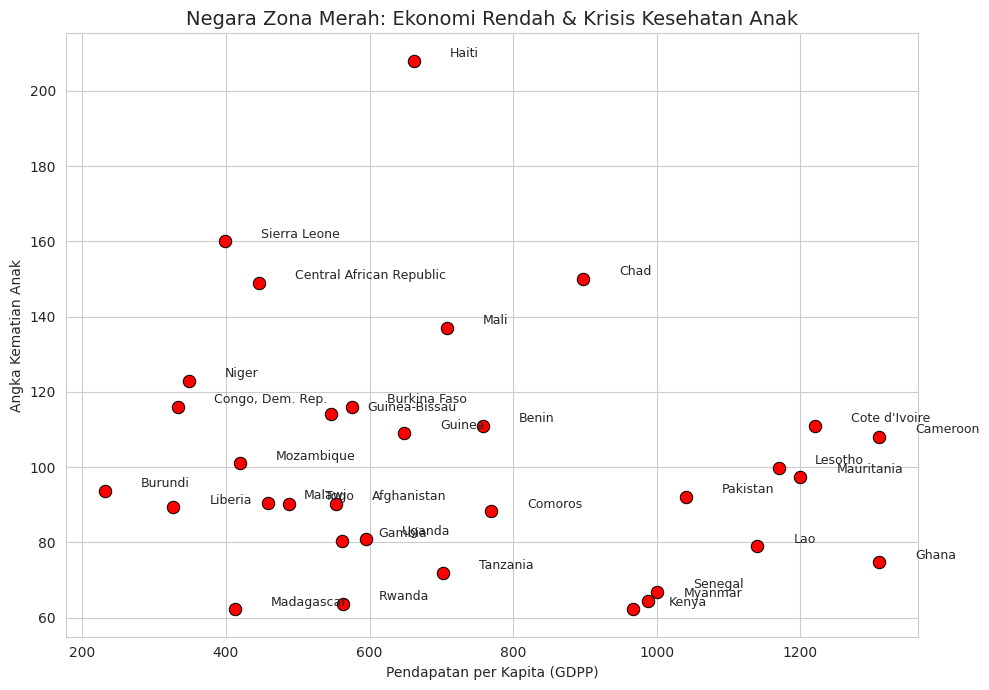

In [ ]:
sns.set_style("whitegrid")

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=negara_zona_merah,
    x='gdpp',
    y='child_mort',
    color='red',
    s=80,
    edgecolor='black'
)

# Label negara
for _, row in negara_zona_merah.iterrows():
    plt.text(
        row['gdpp'] + 50,
        row['child_mort'] + 1,
        row['country'],
        fontsize=9
    )

plt.title("Negara Zona Merah: Ekonomi Rendah & Krisis Kesehatan Anak", fontsize=14)
plt.xlabel("Pendapatan per Kapita (GDPP)")
plt.ylabel("Angka Kematian Anak")

plt.tight_layout()
plt.show()


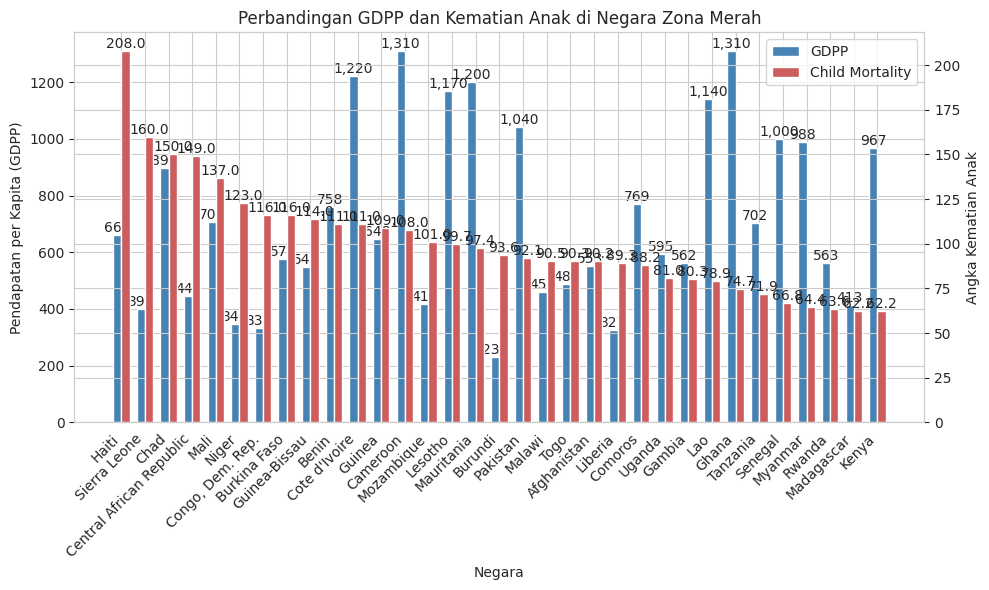

In [ ]:
countries = negara_zona_merah['country']
x = np.arange(len(countries))
width = 0.35

fig, ax1 = plt.subplots(figsize=(10,6))

# Bar GDPP
bar1 = ax1.bar(
    x - width/2,
    negara_zona_merah['gdpp'],
    width,
    label='GDPP',
    color='steelblue'
)
ax1.set_ylabel('Pendapatan per Kapita (GDPP)')
ax1.set_xlabel('Negara')

# Axis kedua untuk child mortality
ax2 = ax1.twinx()
bar2 = ax2.bar(
    x + width/2,
    negara_zona_merah['child_mort'],
    width,
    label='Child Mortality',
    color='indianred'
)
ax2.set_ylabel('Angka Kematian Anak')

# Add data labels for GDPP
ax1.bar_label(bar1, fmt='{:,.0f}')

# Add data labels for Child Mortality
ax2.bar_label(bar2, fmt='{:.1f}')

# X ticks
ax1.set_xticks(x)
ax1.set_xticklabels(countries, rotation=45, ha='right')

# Judul
plt.title("Perbandingan GDPP dan Kematian Anak di Negara Zona Merah")

# Legend gabungan
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
plt.legend(handles1 + handles2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

### Temuan Utama Analisis Data
* Ambang batas kemiskinan (persentil ke-25 PDB per Kapita) dihitung sebesar 1330,0.
* Ambang batas krisis kesehatan (persentil ke-75 Angka Kematian Anak) ditentukan sebesar 62,1.
* Sebanyak 33 negara diidentifikasi berada di 'Zona Merah', artinya mereka memiliki PDB per kapita di bawah $1330,0 dan angka kematian anak di atas 62,1.
* Bagan batang memvisualisasikan angka kematian anak untuk negara-negara 'Zona Merah' ini, dengan Nigeria, Sierra Leone, dan Republik Afrika Tengah menunjukkan angka tertinggi masing-masing sekitar 90,0, 87,0, dan 83,0.

### Wawasan atau Langkah Selanjutnya
* Negara-negara 'Zona Merah' ini mewakili area kritis untuk intervensi karena gabungan angka kematian anak yang tinggi dan output ekonomi yang rendah. Analisis lebih lanjut dapat memprioritaskan negara-negara ini untuk bantuan kemanusiaan.

* Menyelidiki faktor-faktor sosial-ekonomi dan infrastruktur kesehatan spesifik yang berkontribusi terhadap tingginya angka kematian anak di negara-negara 'Zona Merah' teratas untuk mengembangkan strategi intervensi yang tepat sasaran.

# **BAB 5**

## Tugas 5.1 (Pemilihan 10 Negara Prioritas): Dari daftar negara zona merah pada Bab 4, pilih 10 negara dengan angka harapan hidup terendah secara absolut.

In [ ]:
# Tugas 5.1

negara_prioritas = execute("""
WITH threshold AS (
  SELECT
    PERCENTILE_CONT(gdpp, 0.25) OVER() AS ambang_kemiskinan,
    PERCENTILE_CONT(child_mort, 0.75) OVER() AS ambang_krisis_kesehatan
  FROM `da-2025-481513.Country_dataset.country_data`
),

zona_merah AS (
  SELECT
    c.country,
    c.gdpp,
    c.child_mort,
    c.life_expec
  FROM `da-2025-481513.Country_dataset.country_data` c
  CROSS JOIN (
    SELECT DISTINCT ambang_kemiskinan, ambang_krisis_kesehatan
    FROM threshold
  ) t
  WHERE c.gdpp < t.ambang_kemiskinan
    AND c.child_mort > t.ambang_krisis_kesehatan
)

SELECT
  country,
  gdpp,
  child_mort,
  life_expec
FROM zona_merah
ORDER BY life_expec ASC
LIMIT 10;""")

negara_prioritas

,country,gdpp,child_mort,life_expec
0,Haiti,662,208.0,32.1
1,Lesotho,1170,99.7,46.5
2,Central African Republic,446,149.0,47.5
3,Malawi,459,90.5,53.1
4,Mozambique,419,101.0,54.5
5,Sierra Leone,399,160.0,55.0
6,Guinea-Bissau,547,114.0,55.6
7,Afghanistan,553,90.2,56.2
8,Cote d'Ivoire,1220,111.0,56.3
9,Chad,897,150.0,56.5


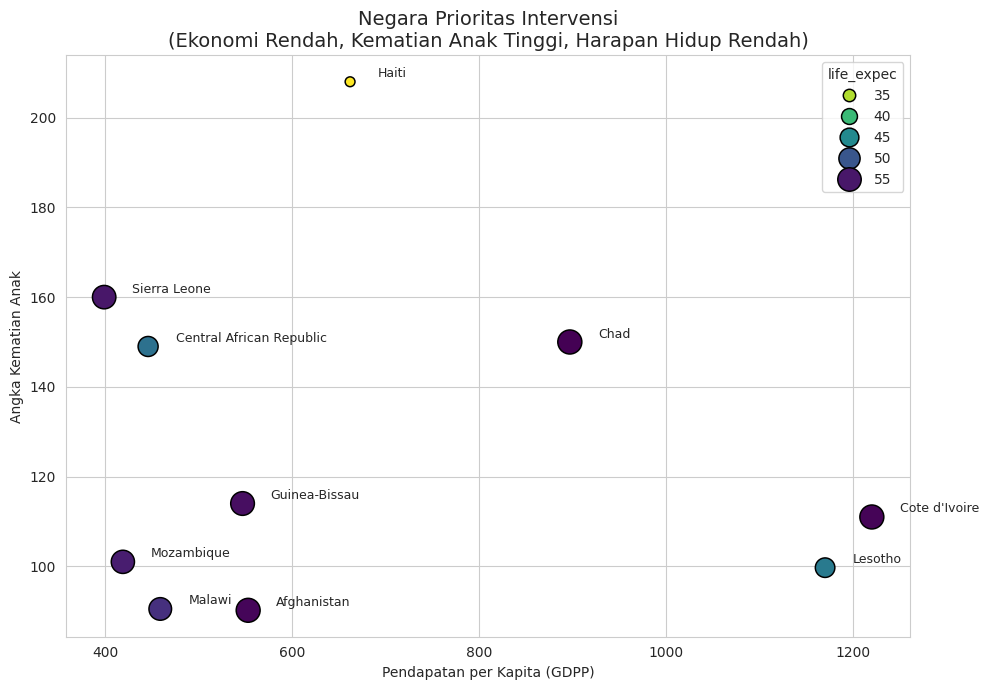

In [ ]:
sns.set_style("whitegrid")

plt.figure(figsize=(10,7))

scatter = sns.scatterplot(
    data=negara_prioritas,
    x='gdpp',
    y='child_mort',
    size='life_expec',          # ukuran berdasarkan life expectancy
    hue='life_expec',           # warna berdasarkan life expectancy
    palette='viridis_r',        # makin gelap = makin kritis
    sizes=(50, 300),
    legend='brief',
    edgecolor='black'
)

# Label nama negara
for _, row in negara_prioritas.iterrows():
    plt.text(
        row['gdpp'] + 30,
        row['child_mort'] + 1,
        row['country'],
        fontsize=9
    )

plt.title(
    "Negara Prioritas Intervensi\n(Ekonomi Rendah, Kematian Anak Tinggi, Harapan Hidup Rendah)",
    fontsize=14
)
plt.xlabel("Pendapatan per Kapita (GDPP)")
plt.ylabel("Angka Kematian Anak")

plt.tight_layout()
plt.show()


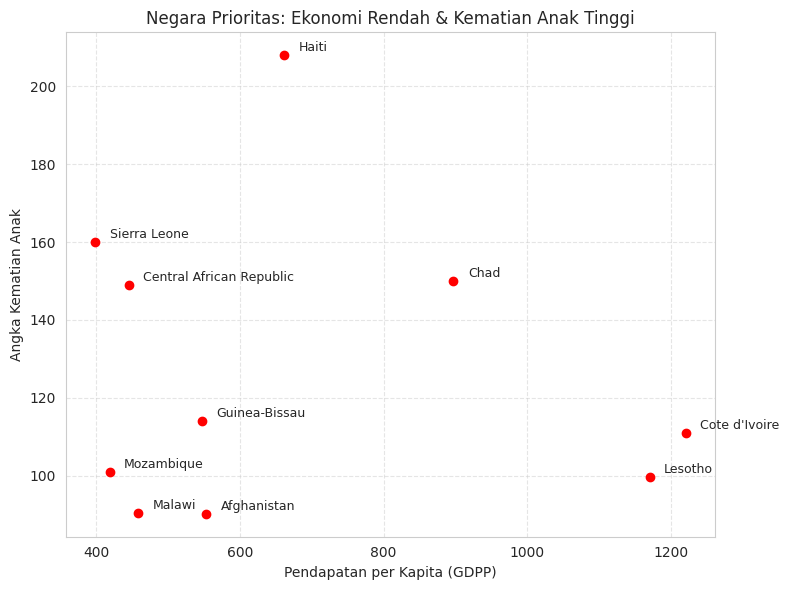

In [ ]:
# Urutkan negara berdasarkan life expectancy (ASC = paling rendah dulu)
negara_prioritas_sorted = negara_prioritas.sort_values(
    by='life_expec',
    ascending=True
).reset_index(drop=True)


plt.figure(figsize=(8,6))

plt.scatter(
    negara_prioritas['gdpp'],
    negara_prioritas['child_mort'],
    color='red'
)

# Tambahkan nama negara
for i in range(len(negara_prioritas)):
    plt.text(
        negara_prioritas['gdpp'][i] + 20,
        negara_prioritas['child_mort'][i] + 1,
        negara_prioritas['country'][i],
        fontsize=9
    )

plt.title("Negara Prioritas: Ekonomi Rendah & Kematian Anak Tinggi")
plt.xlabel("Pendapatan per Kapita (GDPP)")
plt.ylabel("Angka Kematian Anak")

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()